Random_state:  44
              precision    recall  f1-score   support

 non-healing       0.00      0.00      0.00         1
     healing       0.86      1.00      0.92         6

   micro avg       0.75      0.86      0.80         7
   macro avg       0.43      0.50      0.46         7
weighted avg       0.73      0.86      0.79         7
 samples avg       0.79      0.86      0.81         7

Accuracy: 71.42857142857143 %


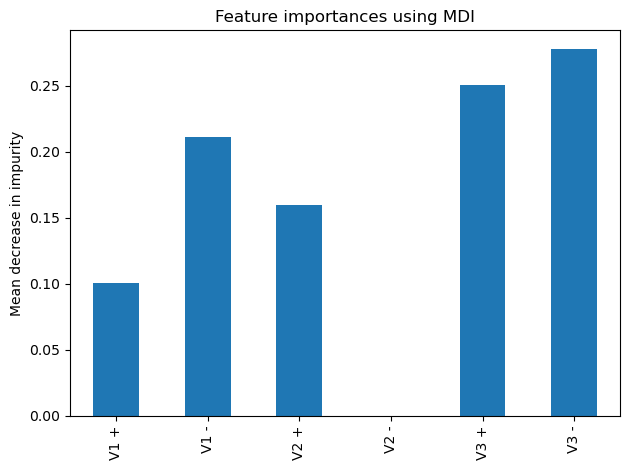

[[0.13727525 0.8626136 ]
 [0.01031294 0.97028214]
 [0.13727525 0.8626136 ]
 [0.56492996 0.50787544]
 [0.13727525 0.8626136 ]
 [0.13727525 0.8626136 ]
 [0.13727525 0.8626136 ]]
[[False  True]
 [False  True]
 [False  True]
 [ True  True]
 [False  True]
 [False  True]
 [False  True]]


<Figure size 40000x12000 with 0 Axes>

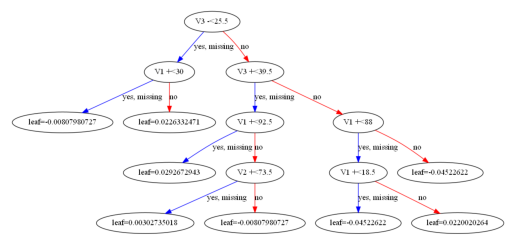

--------------------------------------------------------------------------------------------------


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn import tree
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import pandas as pd
import re
import random
from tensorflow.keras.utils import to_categorical
from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer
import xgboost as xgb
from xgboost import plot_tree
from xgboost import XGBClassifier
from dtreeviz import model

Treatment=pd.read_csv("../dissertation/plus Gran1-3.csv")
df_x=Treatment.iloc[:,1:]
df_y=Treatment.iloc[:,0]
R_state=random.randrange(1,100)
print("Random_state: ",R_state)
#R_state=73
X_train, X_test, y_train, y_test = train_test_split(df_x, df_y,test_size=0.1, random_state=R_state,stratify=df_y)
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)
W_tree=1


names=["V1 +","V1 -", "V2 +","V2 -", "V3 +", "V3 -"]
clf=XGBClassifier(booster="dart",
                  normalize_type="forest",
                  tree_method="exact",
                 objective="reg:pseudohubererror",
                  eta=0.09,
                 # max_depth=4,
                 # subsample=0.9,
                  colsample_bytree=0.7,
                  colsample_bylevel=0.9,
                # colsample_bynode=0.6,
                  reg_lambda=0.8,
                  reg_alpha=0.4,
                  rate_drop=1,
                  skip_drop=0.4,
                  one_drop=1,
                 # sample_type="weighted",
                  
    )

clf=XGBClassifier(tree_method="exact",
                 objective="reg:pseudohubererror",
                 eta=0.09,)

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_pred = (y_pred > 0.5) 

print(classification_report(y_test,y_pred,output_dict=False,target_names=["non-healing","healing"]))


accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", (accuracy*100),"%")

names=clf.get_booster().feature_names

importances = clf.feature_importances_
forest_importances = pd.Series(importances, index=names)

fig, ax = plt.subplots()
forest_importances.plot.bar( ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()
plt.show()

f = open("out.txt", "w")
var=clf.get_booster().get_dump()
for line in var:
    f.write(f"{line}\n")
f.close()

print(clf.predict_proba(X_test))
print(y_pred)


plt.figure(figsize=(400, 120))
plot_tree(clf, num_trees=W_tree)
plt.show()








print("--------------------------------------------------------------------------------------------------")

target = 'key'
class_names=["non-healing","healing"]


#Which_data=df_y_test
Which_data=df_y

from supertree import SuperTree
st = SuperTree(
    clf, 
    X_test, 
    Which_data, 
    names, 
    class_names
)
# Visualize the tree
st.show_tree(which_tree=W_tree)